<a href="https://colab.research.google.com/github/Jorge-Ruiz-Troccoli/Data-Science-II/blob/main/Clase%2012/Regresiones_Enclase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de Regresión
### Coderhouse - Data Science
Profe Jorge Ruiz

In [ ]:
# importamos librerias necesarias
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error as mse
from sklearn.pipeline import Pipeline
from sklearn.preprocessing  import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn import datasets, linear_model

from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
url = 'https://raw.githubusercontent.com/Jorge-89/Regresion-Lineal-/main/base_datos_estaciones_met_V3_train.csv'
df = pd.read_csv(url, sep=",")
df.columns

In [ ]:
#se visualiza las primeras 5 filas
df.head()

In [ ]:
df.drop(["Unnamed: 0", "fecha_completa", "Fecha", "Hora"], inplace=True, axis=1)

In [ ]:
df

In [ ]:
  #Revisar si hay algun faltante en el df
df.isnull().any()


In [ ]:
#observamos como cada columna tiene 10368 datos sin  faltantes.
df.info()

In [ ]:
df.describe()
#veamos los estadísticos básicos

# Se debe comprobar que no hay en la base de datos, valores fisicamente imposibles:
# Humedad relativa mayor al 100% o menor al 0%
# Precipitación negativa
# Valores de temperaturas menores a 0° que seria imposible para la epoca analizada o valores máximos que superen los 50°C

In [ ]:
df.corr()

In [ ]:
x= df[[ 'Temp_Las Varas AgriculturaCba', 'Humedad_Las Varas AgriculturaCba',
        'Temp_San Miguel - Establecimiento Don Luis', 'Humedad_San Miguel - Establecimiento Don Luis',
       'Temp_San Miguel - Listello', 'Humedad_San Miguel - Listello',
       'Temp_ San Miguel - Las Varillas', 'Humedad_ San Miguel - Las Varillas']]
y= df["Temp_Alicia AgriculturaCba"]


In [ ]:
#Separo los datos de "train" en entrenamiento y prueba "test" para probar los algoritmos
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


 # validación cruzada o cross-validation

 revisar más en https://es.wikipedia.org/wiki/Validaci%C3%B3n_cruzada

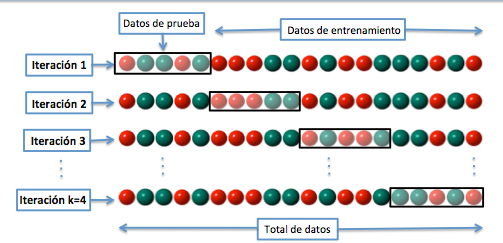

La validación cruzada tiene varios beneficios, por ejemplo:

1) Es una forma de evitar el sesgo de los datos de entrenamiento.

2) Ayuda a evaluar el rendimiento de un modelo con datos nuevos.

3) Comparar diferentes modelos. Al evaluar múltiples modelos en diferentes particiones de datos, se puede determinar cuál tiene un mejor rendimiento en general.




## **Regresión Lineal**

In [ ]:
#puede llegar a  tardar demasiado realizar un CV con polinomios mayores a 5.
modelo = Pipeline([('scaler', StandardScaler()),('features', PolynomialFeatures()),
                    ('regression', LinearRegression())])

hiperparametros={'features__degree':[1,2,3,4]}

grilla=GridSearchCV(modelo,hiperparametros, cv=5,scoring='neg_root_mean_squared_error', return_train_score=True, verbose=3)
grilla.fit(x_train,y_train)

#revisar https://scikit-learn.org/stable/modules/model_evaluation.html



In [ ]:
print(grilla.best_params_)
#Mejor polinomio es de grado 3



In [ ]:
grilla.best_estimator_

In [ ]:
grilla.best_score_

In [ ]:
grilla.cv_results_

In [ ]:
for ni, i in enumerate(grilla.cv_results_['params']):
  print(i['features__degree'],-grilla.cv_results_['mean_test_score'][ni])
plt.errorbar(grilla.cv_results_['param_features__degree'].data,(-grilla.cv_results_['mean_test_score']),yerr=grilla.cv_results_['std_test_score'])
plt.yscale('log')
plt.xlabel('grado')
plt.ylabel('RMSE en validacion')


In [ ]:
# entrenamos con el mejor modelo
modelo_lineal=grilla.best_estimator_
modelo_lineal.fit(x_train, y_train)

In [ ]:
#hago las predicciones con x_test, x_train
y_pred_test = modelo_lineal.predict(x_test)
y_pred_train = modelo_lineal.predict(x_train)


In [ ]:
from sklearn.metrics import root_mean_squared_error
print('Precisión del modelo usando el error cuadratico medio (RMSE):')

score_train_modelo_lineal = root_mean_squared_error(y_train,y_pred_train)
score_test_modelo_lineal = root_mean_squared_error(y_test,y_pred_test)

print ("Train:", score_train_modelo_lineal)
print ("Testeo:", score_test_modelo_lineal)


 Recordar que cuanto menor sea el valor del RMSE, más precisas serán las predicciones del modelo en relación con los valores reales.

El RMSE tiene la misma unidad de medida que la variable objetivo del problema de regresión, lo que lo hace fácilmente interpretable y comparable con el rango de los valores reales

In [ ]:
# Obtiene los coeficientes del modelo de regresión lineal ajustado y= x1+x2+x3... e
coeficientes = modelo_lineal.named_steps['regression'].coef_
coeficientes

# Random Forest (RF)

In [ ]:
RF = RandomForestRegressor()
hiperparametros={'max_depth':[5,9],'min_samples_leaf':[1], 'max_leaf_nodes':[9,12], 'n_estimators':[80,100]}
grilla=GridSearchCV(RF,hiperparametros,cv=3,scoring='neg_root_mean_squared_error', verbose=3)
grilla.fit(x_train,y_train)

#max_depth: define la profundidad máxima permitida
#min_samples_leaf: establece el número mínimo de muestras requeridas en un nodo hoja del árbol.
#max_leaf_nodes: limita el número máximo de nodos hoja que puede tener un árbol
#n_estimators:  indica la cantidad de árboles


In [ ]:
grilla.best_params_

In [ ]:
grilla.best_score_

In [ ]:
# Fit best model
modelo_RF=grilla.best_estimator_
modelo_RF.fit(x_train, y_train)

In [ ]:
#hago las predicciones con x_test, x_train
y_pred_test = modelo_RF.predict(x_test)
y_pred_train = modelo_RF.predict(x_train)


In [ ]:

print('Precisión del modelo usando la raíz del error cuadratico medio (RMSE):')

score_train_modelo_RF = root_mean_squared_error(y_train,y_pred_train)
score_test_modelo_RF = root_mean_squared_error(y_test,y_pred_test)

print ("Train:", score_train_modelo_RF)
print ("Testeo:", score_test_modelo_RF)



In [ ]:
# Obtener la importancia de las variables



importancia_predictores = pd.DataFrame(
                            {'predictores': x.columns,
                             'importancia':  modelo_RF.feature_importances_
}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

# Support Vector Machine (SVM)

In [ ]:
pipeline= Pipeline([('scaler', StandardScaler()),
                  ('modelo',SVR())])

hiperparametros=[{'modelo__C':[10,5],'modelo__kernel':['linear']},{'modelo__gamma':[0.01,0.1], 'modelo__C':[1,2],'modelo__kernel':['rbf']}]
grilla=GridSearchCV(pipeline,hiperparametros, cv=2,scoring='neg_root_mean_squared_error',n_jobs=-1,verbose=3)
grilla.fit(x_train,y_train)

#C: controla el término de regularización y determina la penalización aplicada a los errores en la clasificación.Un valor más alto de C indica una penalización más fuerte

#kernel:  especifica el tipo de kernel a utilizar en SVM. En este caso, se consideran dos opciones: 'linear' y 'rbf' (función de base radial)

#gamma: influye en la flexibilidad de la frontera de decisión  con kernel 'rbf'.
#gamma un valor más bajo de gamma resulta en fronteras de decisión más suaves y más generalizadas, mientras que un valor más alto de gamma genera fronteras de decisión más ajustadas a los puntos de datos de entrenamiento y puede llevar a un sobreajuste.


In [ ]:
grilla.best_params_


In [ ]:
grilla.best_score_

In [ ]:
# Fit best model
modelo_SVR=grilla.best_estimator_
modelo_SVR.fit(x_train, y_train)

In [ ]:
#hago las predicciones con x_test, x_train
y_pred_test = modelo_SVR.predict(x_test)
y_pred_train = modelo_SVR.predict(x_train)


In [ ]:

print('Precisión del modelo usando la raíz del error cuadratico medio (MSE):')

score_train_modelo_SVR = mean_squared_error(y_train,y_pred_train)
score_test_modelo_SVR = mean_squared_error(y_test,y_pred_test)

print ("Train:", score_train_modelo_SVR)
print ("Testeo:", score_test_modelo_SVR)

#Si utilizan squared=True en la función mean_squared_error, obtendrán el MSE

Hasta el momento, el mejor modelo lo obtuvimos con un polinomio de grado 3.

# KNN

In [ ]:
pipeline= Pipeline([('scaler', StandardScaler()),
                  ('modelo',KNeighborsRegressor())])

hiperparametros={'modelo__n_neighbors':[1,2,3,4,5,6,7,8]}
grilla=GridSearchCV(pipeline,hiperparametros, cv=5,scoring='neg_root_mean_squared_error',n_jobs=-1,verbose=3)
grilla.fit(x_train,y_train)


In [ ]:
grilla.best_params_


In [ ]:
grilla.best_score_

In [ ]:
# Fit best model
modelo_KNN=grilla.best_estimator_
modelo_KNN.fit(x_train, y_train)

In [ ]:
#hago las predicciones con x_test, x_train
y_pred_test = modelo_KNN.predict(x_test)
y_pred_train = modelo_KNN.predict(x_train)

In [ ]:
print('Precisión del modelo usando la raíz del error cuadratico medio (MSE):')

score_train_modelo_KNN = mean_squared_error(y_train,y_pred_train)
score_test_modelo_KNN = mean_squared_error(y_test,y_pred_test)

print ("Train:", score_train_modelo_KNN)
print ("Testeo:", score_test_modelo_KNN)

#Si utilizan squared=True en la función mean_squared_error, obtendrán el MSE

In [ ]:
from sklearn.inspection import permutation_importance


# Calcular la importancia de las características
resultado = permutation_importance(modelo_KNN, x_train, y_train, scoring='neg_root_mean_squared_error', random_state=42)
importancias= resultado.importances_mean

# Mostrar la importancia de las características
for i, importancia in enumerate(x.columns):
    print(f"Importancia de {importancia}: {importancias[i]:.4f}")


# revisar https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html

# https://medium.com/@TheDataScience-ProF/permutation-importance-c784e3f8a439

In [ ]:
# Calcular la importancia de las características
resultado = permutation_importance(modelo_RF, x_train, y_train, scoring='neg_root_mean_squared_error', random_state=42)
importancias= resultado.importances_mean

# Mostrar la importancia de las características
for i, importancia in enumerate(x.columns):
    print(f"Importancia de {importancia}: {importancias[i]:.4f}")


In [ ]:
# como funciona un for con enumarate

# Definimos una lista de autos
autos = ['gol', 'clio', 'fiesta', 'uno']

# Utilizamos enumerate() para obtener tanto el índice como el valor de cada elemento en la lista
for indice, auto in enumerate(autos):
    print(f"El auto en el índice {indice} es {auto}")

In [ ]:
import pickle

# Supongamos que tienes un modelo entrenado llamado "dt"
modelo = modelo_KNN

# Guardamos el modelo en un archivo utilizando pickle
with open('modelo_kNN_2.pkl', 'wb') as archivo:
    pickle.dump(modelo_KNN, archivo)

In [ ]:
# ahora veamos como usarlo a futuro

# Cargamos el modelo
with open('modelo_kNN_2.pkl', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)

# Utilizar el modelo cargado para hacer predicciones, por ejemplo:
predicciones = modelo_cargado.predict(x_test)
predicciones

In [ ]:
y_test = y_test.to_numpy()


In [ ]:
from matplotlib import pyplot
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt

pyplot.style.use('ggplot')

figure(figsize=(8, 6), dpi=80)


pyplot.plot(predicciones[:50])
pyplot.plot(y_test[:50])
plt.legend(['Estimado','Real'])
plt.xlabel('Eje de las x')
plt.ylabel('Eje de las y')
plt.show()

Aunque pueda parecer poco, medio grado centígrado más de temperatura global tendría unos efectos enormes sobre nuestro planeta.

Por ejemplo, si la temperatura aumenta 2 °C, el hielo del ártico desaparecerá por completo en uno de cada diez veranos, y no en uno de cada cien como pasaría con un aumento del 1,5 °C. Estimar con la mayor precisión posible la temperatura hace que se pueda monitorear y llegar a conclusiones certeras si hay un aumento o no de la temperatura  

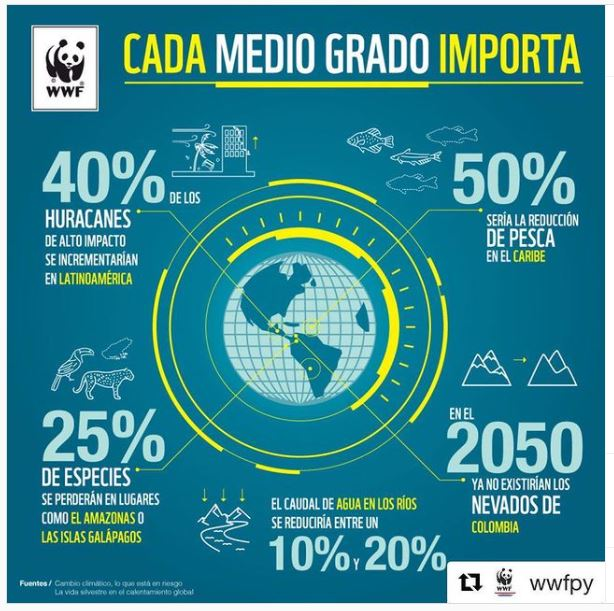